### Introduction to Convulotional Nerual Network & Computer Vision

- Computer vision: A branch of artificial intelligence that trains machines to interpret and understand digital images and videos. Example: How self-driving car make a decision through camera attached on them.

📝**NOTE**: For now im started the CNN with food101 data, a dataset contain 101 differect food classes. However i found this edited food101 dataset where it's only contain 2 classes (steak & pizza) instead of 101 classes of food.
link: https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

### EDA

In [1]:
import os

for dirpath, dirnames, filenames in os.walk(r"D:\Python Course\Tensorflow Crash Course\data\pizza_steak"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")


There are 2 directories and 0 images in 'D:\Python Course\Tensorflow Crash Course\data\pizza_steak'.
There are 2 directories and 0 images in 'D:\Python Course\Tensorflow Crash Course\data\pizza_steak\test'.
There are 0 directories and 250 images in 'D:\Python Course\Tensorflow Crash Course\data\pizza_steak\test\pizza'.
There are 0 directories and 250 images in 'D:\Python Course\Tensorflow Crash Course\data\pizza_steak\test\steak'.
There are 2 directories and 0 images in 'D:\Python Course\Tensorflow Crash Course\data\pizza_steak\train'.
There are 0 directories and 750 images in 'D:\Python Course\Tensorflow Crash Course\data\pizza_steak\train\pizza'.
There are 0 directories and 750 images in 'D:\Python Course\Tensorflow Crash Course\data\pizza_steak\train\steak'.


In [2]:
num_steak_images_train = len(os.listdir(r"D:\Python Course\Tensorflow Crash Course\data\pizza_steak\train\steak"))

num_steak_images_train

750

To viusalize our images, first let's get the class names.

In [5]:
import pathlib
import numpy as np
data_dir = pathlib.Path(r"D:\Python Course\Tensorflow Crash Course\data\pizza_steak\train")
class_names = np.array(sorted([item.name for item in data_dir.glob("*")]))
print(class_names)

['pizza' 'steak']


In [17]:
# Visualize images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def rand_image(targer_dir, target_class):
    
    target_folder = targer_dir+target_class
    
    # Get a random image page
    rand_image = random.sample(os.listdir(target_folder), 1)
    print(rand_image)
    
    # Plot the image
    img = mpimg.imread(target_folder+"/"+rand_image[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")
    
    print(f"Image shape: {img.shape}")
    
    # return img


['3366256.jpg']
Image shape: (512, 512, 3)


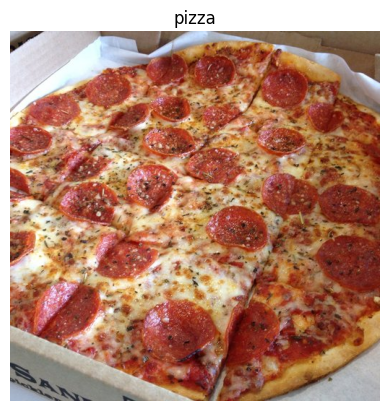

In [27]:
rand_image(targer_dir=r"D:\Python Course\Tensorflow Crash Course\data\pizza_steak\train\\",
           target_class="pizza")

### Build End to End Model

Let's build a convolutional neural network to find patterns in our images, more specifically we need a way to:

- Load images
- Preprocessing images
- Build CNN to find patterns of images
- Compile our CNN
- Fit the CNN to training data

In [36]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set random seed
tf.random.set_seed(42)

# Preprocessing data (Scalling/Normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Data directiory
train_dir = r"D:\Python Course\Tensorflow Crash Course\data\pizza_steak\train"
test_dir = r"D:\Python Course\Tensorflow Crash Course\data\pizza_steak\test"

# Import data from dir
train_data = train_datagen.flow_from_directory(directory=train_dir, batch_size=32, 
                                               target_size=(224,224), class_mode="binary",
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(directory=test_dir, batch_size=32, 
                                               target_size=(224,224), class_mode="binary",
                                               seed=42)

# Build CNN model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10, kernel_size=3,
                           activation="relu", input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2, padding="valid"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile CNN Model
model_1.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit model
history_1 = model_1.fit(train_data, epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps= len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


c:\Users\Diandra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 30s 611ms/step - accuracy: 0.5706 - loss: 0.6921 - val_accuracy: 0.7520 - val_loss: 0.5210
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 296ms/step - accuracy: 0.7494 - loss: 0.5053 - val_accuracy: 0.8020 - val_loss: 0.4527
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 288ms/step - accuracy: 0.7986 - loss: 0.4396 - val_accuracy: 0.8420 - val_loss: 0.3802
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 284ms/step - accuracy: 0.8178 - loss: 0.4199 - val_accuracy: 0.7660 - val_loss: 0.4695
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 293ms/step - accuracy: 0.8049 - loss: 0.4248 - val_accuracy: 0.8420 - val_loss: 0.3558
